# Mini Project 3: Improving Customer Experience at McDonald’s through Review Analysis and Clustering

# 1. Import libraries

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# 2. Load data from Kaggle

In [203]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/mcdonalds-store-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/mcdonalds-store-reviews


## Load the CSV

In [204]:
csv_path = os.path.join(path, "McDonald_s_Reviews.csv")
df = pd.read_csv(csv_path, encoding='latin1')

## View the first 5 rows

In [205]:
df.head()

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
0,1,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",3 months ago,Why does it look like someone spit on my food?...,1 star
1,2,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,It'd McDonalds. It is what it is as far as the...,4 stars
2,3,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",5 days ago,Made a mobile order got to the speaker and che...,1 star
3,4,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",a month ago,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5 stars
4,5,McDonald's,Fast food restaurant,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,"1,240",2 months ago,"I repeat my order 3 times in the drive thru, a...",1 star


In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33396 entries, 0 to 33395
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewer_id    33396 non-null  int64  
 1   store_name     33396 non-null  object 
 2   category       33396 non-null  object 
 3   store_address  33396 non-null  object 
 4   latitude       32736 non-null  float64
 5   longitude      32736 non-null  float64
 6   rating_count   33396 non-null  object 
 7   review_time    33396 non-null  object 
 8   review         33396 non-null  object 
 9   rating         33396 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.5+ MB


In [207]:
df.describe(include='all')

,reviewer_id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review,rating
count,33396.000000,33396,33396,33396,32736.000000,32736.000000,33396,33396,33396,33396
unique,NaN,2,1,40,NaN,NaN,51,39,22285,5
top,NaN,McDonald's,Fast food restaurant,"9814 International Dr, Orlando, FL 32819, Unit...",NaN,NaN,"2,193",4 years ago,Excellent,5 stars
freq,NaN,33325,33396,1890,NaN,NaN,1140,6740,2148,10274
mean,16698.500000,NaN,NaN,NaN,34.442546,-90.647033,NaN,NaN,NaN,NaN
std,9640.739131,NaN,NaN,NaN,5.344116,16.594844,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,25.790295,-121.995421,NaN,NaN,NaN,NaN
25%,8349.750000,NaN,NaN,NaN,28.655350,-97.792874,NaN,NaN,NaN,NaN
50%,16698.500000,NaN,NaN,NaN,33.931261,-81.471414,NaN,NaN,NaN,NaN
75%,25047.250000,NaN,NaN,NaN,40.727401,-75.399919,NaN,NaN,NaN,NaN


### Choose Data Relevant to the Problem Statement

In [208]:
# Strip whitespace from all column names
df.columns = df.columns.str.strip()

# Select relevant columns
df_subset = df[['store_address', 'review', 'rating']]

### Clean the data


In [209]:
# Check for missing data
df_subset.isnull().sum()

,0
store_address,0
review,0
rating,0


### Update rating column to integers

In [210]:
df_subset["rating"] = df_subset["rating"].str[0].astype(int)

/tmp/ipython-input-210-611407879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset["rating"] = df_subset["rating"].str[0].astype(int)


In [211]:
df_subset.head()

,store_address,review,rating
0,"13749 US-183 Hwy, Austin, TX 78750, United States",Why does it look like someone spit on my food?...,1
1,"13749 US-183 Hwy, Austin, TX 78750, United States",It'd McDonalds. It is what it is as far as the...,4
2,"13749 US-183 Hwy, Austin, TX 78750, United States",Made a mobile order got to the speaker and che...,1
3,"13749 US-183 Hwy, Austin, TX 78750, United States",My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,5
4,"13749 US-183 Hwy, Austin, TX 78750, United States","I repeat my order 3 times in the drive thru, a...",1


### Clean review text

In [212]:
# Define a function to clean review text
def clean_review_text(text):
    text = text.lower()                             # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)            # Remove non-letter characters
    text = re.sub(r'\s+', ' ', text).strip()        # Remove extra spaces
    return text

# Apply the cleaning function to the review column
df_cleaned = df_subset.copy()
df_cleaned["cleaned_review"] = df_cleaned["review"].astype(str).apply(clean_review_text)

# Show a sample of the cleaned text
df_cleaned[["review", "cleaned_review"]].head()

,review,cleaned_review
0,Why does it look like someone spit on my food?...,why does it look like someone spit on my food ...
1,It'd McDonalds. It is what it is as far as the...,itd mcdonalds it is what it is as far as the f...
2,Made a mobile order got to the speaker and che...,made a mobile order got to the speaker and che...
3,My mc. Crispy chicken sandwich was ï¿½ï¿½ï¿½ï¿...,my mc crispy chicken sandwich was customer ser...
4,"I repeat my order 3 times in the drive thru, a...",i repeat my order times in the drive thru and ...


# 3. Exploratory Data Analysis

## Present Data-driven Insights

### 1. Distribution of review ratings

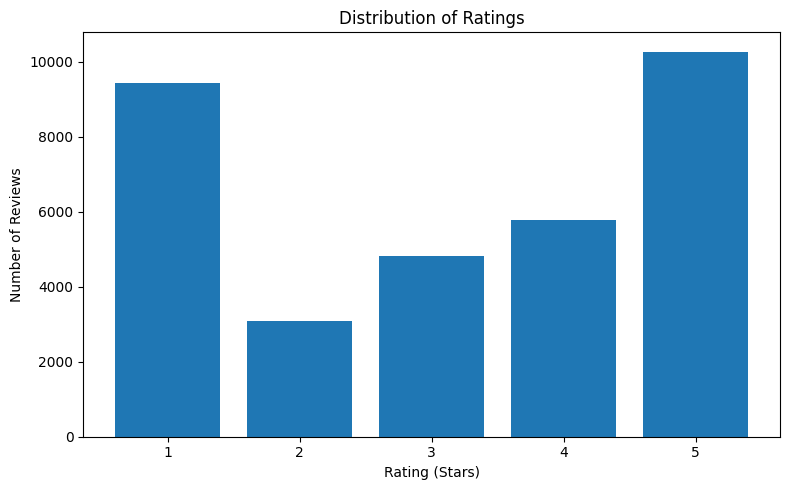

In [213]:
# Extract rating counts
rating_counts = df_cleaned['rating'].value_counts().sort_index()

# Plot bar plot
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)
plt.title("Distribution of Ratings")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Reviews")
plt.xticks(rating_counts.index)
plt.tight_layout()
plt.show()

### 2. Average rating of the 5 worst stores

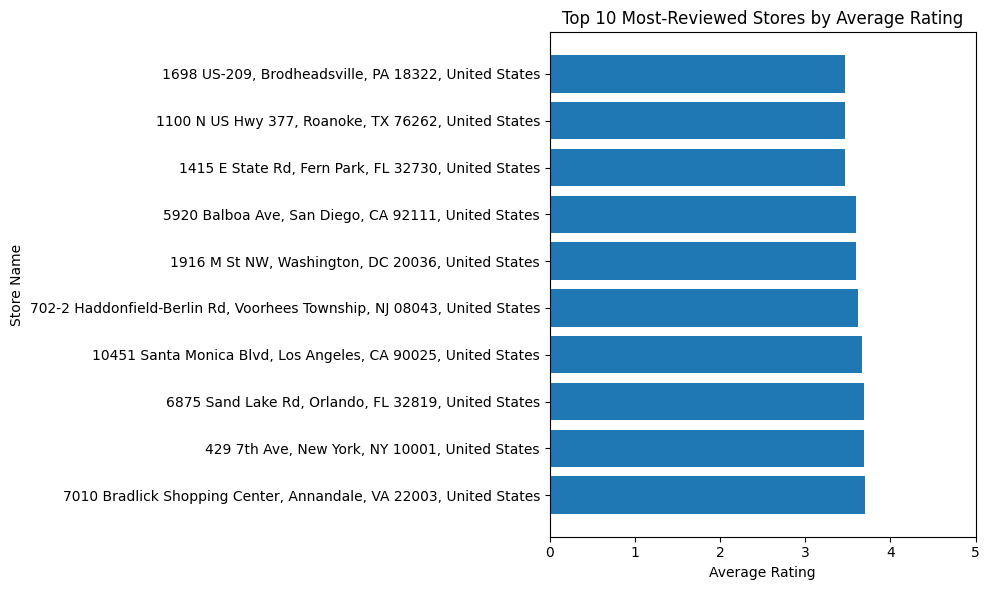

In [214]:
# Extract top 10 stores by average rating
top_stores = df_cleaned.groupby("store_address").agg(
    avg_rating=("rating", "mean"),
    review_count=("rating", "count")
).sort_values("review_count", ascending=False)

top_stores_plot = top_stores.sort_values("avg_rating", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_stores_plot.index, top_stores_plot["avg_rating"])
plt.title("Top 10 Most-Reviewed Stores by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Store Name")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

### 3. Word Cloud of Most Common Words in Customer Reviews

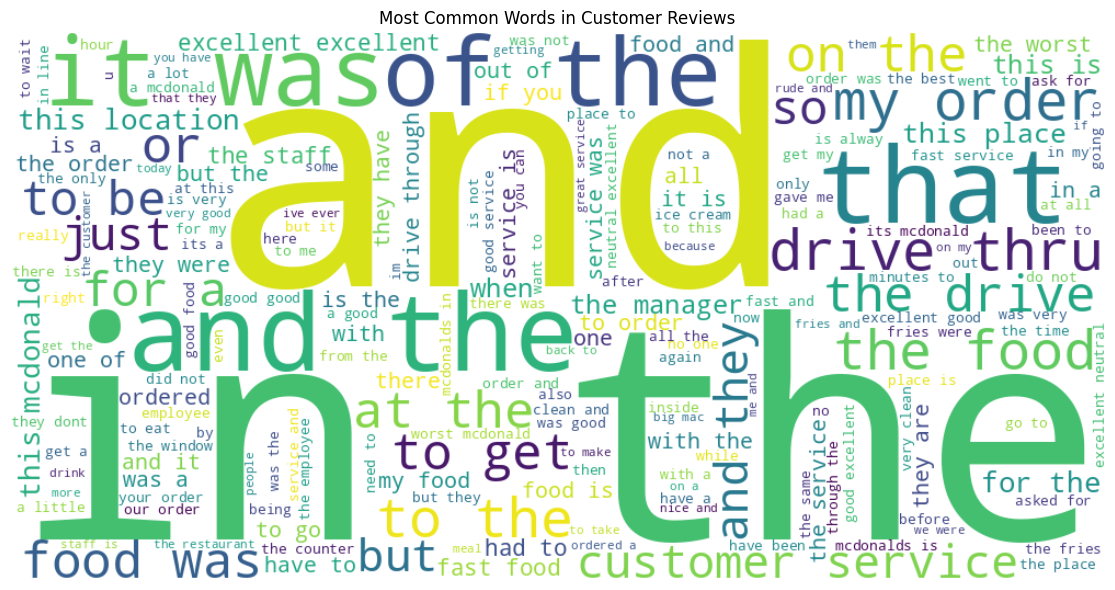

In [215]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned reviews
text = " ".join(df_cleaned["cleaned_review"])

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200,
    stopwords='english'
).generate(text)

# Display it
plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Customer Reviews")
plt.tight_layout()
plt.show()


# 4. Apply Unsupervised Learning Models!

## Text Vectorisation

In [216]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use cleaned review text
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(df_cleaned["cleaned_review"])

## Dimensionality Reduction (PCA)

In [217]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())

## Clustering (K-Means)

In [218]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Add cluster label to your dataframe
df_cleaned['cluster'] = clusters

#### View which words are most important in each cluster

In [219]:
# Inverse transform to get words from vectorised matrix
words = tfidf.get_feature_names_out()
X_clustered = pd.DataFrame(X_tfidf.toarray(), columns=words)
X_clustered['cluster'] = df_cleaned['cluster'].values

# Compute average TF-IDF score for each word per cluster
top_words_by_cluster = (
    X_clustered.groupby("cluster")
    .mean()
    .apply(lambda x: x.sort_values(ascending=False).head(10), axis=1)
)
top_words_by_cluster

,attention,clean,coffee,customer,drive,excellent,fast,food,good,great,...,order,place,price,probably,problem,professional,quick,service,staff,thanks
cluster,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,0.023192,NaN,0.031444,0.045885,NaN,0.031811,...,0.036699,0.027196,NaN,NaN,NaN,NaN,NaN,0.047421,0.021929,NaN
1,0.001885,NaN,NaN,0.001497,NaN,0.989876,0.001254,0.002867,0.000388,NaN,...,NaN,0.002150,NaN,NaN,NaN,NaN,NaN,0.010914,0.001077,0.00077
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004008,0.997922,NaN,...,NaN,0.000288,0.0,0.0,0.0,0.0,0.000377,0.004156,NaN,NaN
3,NaN,0.034325,NaN,NaN,NaN,NaN,0.042743,0.092428,0.254374,0.025443,...,NaN,0.043228,NaN,NaN,NaN,NaN,NaN,0.074974,0.027295,NaN
4,NaN,0.030091,0.021199,0.023853,NaN,NaN,0.086740,0.176834,0.565928,NaN,...,NaN,0.056014,NaN,NaN,NaN,NaN,0.020711,0.190199,NaN,NaN


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


Top words

Cluster 0: drive, fast, food, great, order, place. Theme: Speed, drive-thru service, and food quality

Cluster 1: excellent, attention, customer. Theme: Highly positive reviews focused on excellent service

Cluster 2: 	food, good, price, neutral. Theme: Comments about food quality and value

Cluster 3: 	clean, fast, food, good, great, hot. Theme: Positive emphasis on cleanliness and food freshness

Cluster 4: 	clean, coffee, customer, food, fast, price. Theme: Service + beverage quality and customer care feedback

## Visualise Clusters

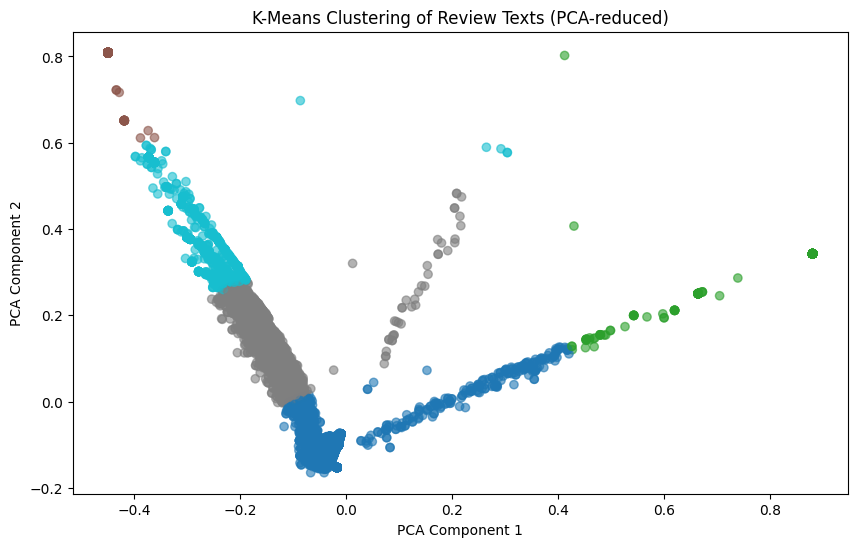

In [220]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.6)
plt.title("K-Means Clustering of Review Texts (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## Topic Modelling (LDA)

In [221]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X_tfidf)

# Show top words per topic
terms = tfidf.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[-10:]]
    print(f"Topic #{idx+1}: {', '.join(top_terms)}")

Topic #1: friendly, mcdonald, customer, quick, food, great, fast, service, excellent, good
Topic #2: time, open, service, mcdonalds, rude, long, order, drive, love, terrible
Topic #3: worst, mcdonalds, ordered, minutes, got, just, like, fries, food, order
Topic #4: fast, ok, mcdonalds, great, food, nice, staff, friendly, place, clean
Topic #5: food, service, hot, bad, best, slow, fresh, poor, mcdonalds, neutral


# 5. Apply Supervised Learning Models!

In [222]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Prepare data
X = df_cleaned["cleaned_review"]
y = df_cleaned["rating"]

# Step 2: Use TF-IDF with more features and bigrams
X_tfidf =  tfidf.fit_transform(X)

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Train logistic regression with stronger regularisation
model = LogisticRegression(max_iter=2000, C=1.5, class_weight='balanced')
model.fit(X_train, y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5766467065868264
Classification Report:
               precision    recall  f1-score   support

           1       0.74      0.67      0.70      1886
           2       0.26      0.42      0.32       617
           3       0.41      0.46      0.44       964
           4       0.49      0.51      0.50      1158
           5       0.76      0.63      0.69      2055

    accuracy                           0.58      6680
   macro avg       0.53      0.54      0.53      6680
weighted avg       0.61      0.58      0.59      6680



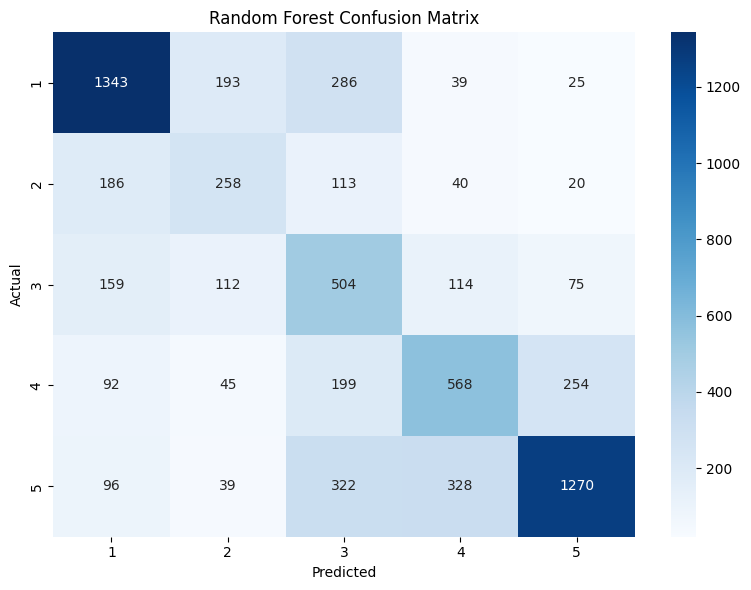

(0.5902694610778443,
 '              precision    recall  f1-score   support\n\n           1       0.72      0.71      0.71      1886\n           2       0.40      0.42      0.41       617\n           3       0.35      0.52      0.42       964\n           4       0.52      0.49      0.51      1158\n           5       0.77      0.62      0.69      2055\n\n    accuracy                           0.59      6680\n   macro avg       0.55      0.55      0.55      6680\nweighted avg       0.62      0.59      0.60      6680\n')

In [223]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Train a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_rf)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

rf_accuracy, rf_report